# ASSIGNMENT CDS

# Problem Statement

Study analysis on the public sentiment towards a company and its stock effect their prices by extracting opinions from Twitter in determining whether public opinion has impact on the stock prices of the company.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sys
from collections import Counter

# Load dataset
df = pd.read_csv("dataset.csv")

print(f"Dataset loaded successfully!")
print(f"Total rows: {len(df):,}")
print(f"Total columns: {df.shape[1]}")
df.head()

Dataset loaded successfully!
Total rows: 1,395,450
Total columns: 14


C:\Users\hafiz\AppData\Local\Temp\ipykernel_3340\1689644038.py:10: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset.csv")


,Unnamed: 0,TWEET,STOCK,DATE,LAST_PRICE,1_DAY_RETURN,2_DAY_RETURN,3_DAY_RETURN,7_DAY_RETURN,PX_VOLUME,VOLATILITY_10D,VOLATILITY_30D,LSTM_POLARITY,TEXTBLOB_POLARITY
0,0,RT @robertoglezcano: @amazon #Patents Show Fl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Amazon,31/01/2017,823.48,0.008379,0.014924,0.014924,-0.001263,3.137196e+06,13.447,16.992,1.000,0.0,NaN
2,1,@FAME95FM1 Jamaicans make money with @Payoneer...,PayPal,31/01/2017,39.780000,0.002011,0.012318,0.012318,5.480141e-02,9100057.000,18.769,16.099,-1.0,0.0
3,2,@CBSi Jamaicans make money with @Payoneer @Pay...,PayPal,31/01/2017,39.780000,0.002011,0.012318,0.012318,5.480141e-02,9100057.000,18.769,16.099,1.0,0.0
4,3,@Hitz92fm Jamaicans make money with @Payoneer ...,PayPal,31/01/2017,39.780000,0.002011,0.012318,0.012318,5.480141e-02,9100057.000,18.769,16.099,-1.0,0.0


# Exploratory Data Analysis (EDA)
- Column names
- Missing values
- Duplicate rows
- Data types
- Date range
- Number of tweets per company/stock
- Number of tweets per date

## General Dataset Overview

In [2]:
# --- 1. Column names and data types ---
print("=" * 50)
print("COLUMN NAMES AND DATA TYPES")
print("=" * 50)
print(df.dtypes)
print()

COLUMN NAMES AND DATA TYPES
Unnamed: 0            object
TWEET                 object
STOCK                 object
DATE                  object
LAST_PRICE           float64
1_DAY_RETURN         float64
2_DAY_RETURN         float64
3_DAY_RETURN         float64
7_DAY_RETURN         float64
PX_VOLUME            float64
VOLATILITY_10D       float64
VOLATILITY_30D       float64
LSTM_POLARITY        float64
TEXTBLOB_POLARITY    float64
dtype: object



In [3]:
# --- 2. Shape of the dataset (rows, columns) ---
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print()

DATASET SHAPE
Rows    : 1,395,450
Columns : 14



In [4]:
# --- 3. Missing values per column ---
print("=" * 50)
print("MISSING VALUES PER COLUMN")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum():,}")

MISSING VALUES PER COLUMN
                   Missing Count  Missing %
Unnamed: 0                293437      21.03
TWEET                         52       0.00
STOCK                     533219      38.21
DATE                      533219      38.21
LAST_PRICE                533219      38.21
1_DAY_RETURN              533219      38.21
2_DAY_RETURN              533219      38.21
3_DAY_RETURN              533219      38.21
7_DAY_RETURN              533219      38.21
PX_VOLUME                 533219      38.21
VOLATILITY_10D            533320      38.22
VOLATILITY_30D            533266      38.21
LSTM_POLARITY             734348      52.62
TEXTBLOB_POLARITY        1027785      73.65

Total missing values: 7,387,960


In [5]:
# --- 4. Duplicate rows ---
print("=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count:,}")
if duplicate_count > 0:
    print("Removing duplicates...")
    df = df.drop_duplicates()
    print(f"Rows after removing duplicates: {len(df):,}")

DUPLICATE ROWS
Number of duplicate rows: 414,040
Removing duplicates...
Rows after removing duplicates: 981,410


In [6]:
# --- 5. Basic descriptive statistics for numerical columns ---
print("=" * 50)
print("DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)")
print("=" * 50)
df.describe()

DESCRIPTIVE STATISTICS (NUMERICAL COLUMNS)


,LAST_PRICE,1_DAY_RETURN,2_DAY_RETURN,3_DAY_RETURN,7_DAY_RETURN,PX_VOLUME,VOLATILITY_10D,VOLATILITY_30D,LSTM_POLARITY,TEXTBLOB_POLARITY
count,486798.000000,486798.000000,486798.000000,4.867980e+05,4.867980e+05,4.867980e+05,486755.000000,486751.000000,432365.000000,367665.000000
mean,1268.418498,0.000959,0.001633,1.329416e+06,1.848101e+06,1.332350e+07,21.515470,18.929150,0.122157,0.076176
std,6241.165026,0.019695,0.025862,6.463510e+06,7.534685e+06,1.927517e+07,17.412226,15.096233,0.925400,0.261048
min,-0.173554,-0.177851,-0.204959,-2.049587e-01,-2.049587e-01,1.000000e+00,-1.000000,-1.000000,-1.000000,-1.000000
25%,8.990000,-0.006024,-0.009992,-1.016673e-02,-1.367309e-02,3.856000e+03,13.186000,9.535000,-1.000000,0.000000
50%,84.230000,0.000000,0.000000,2.162162e-03,1.387629e-02,4.756426e+06,18.911000,19.790000,0.485227,0.000000
75%,339.170000,0.005648,0.010996,2.504923e-02,1.805855e-01,1.922278e+07,25.798000,23.559000,1.000000,0.150000
max,165500.000000,0.243639,0.267113,3.081068e+08,1.562074e+08,3.148332e+08,124.137000,87.685000,1.000000,1.000000


## Stock Exploratory Data Analysis

In [7]:
# --- Number of tweets per company/stock ---
print("=" * 50)
print("NUMBER OF TWEETS PER STOCK/COMPANY")
print("=" * 50)
stock_counts = df['STOCK'].value_counts()
print(stock_counts)
print(f"\nTotal unique stocks/companies: {df['STOCK'].nunique()}")

NUMBER OF TWEETS PER STOCK/COMPANY
STOCK
Ford        52198
Facebook    40837
Google      33697
Next        32606
Apple       27940
            ...  
183.52          1
215.56          1
137.5           1
265.37          1
5404.0          1
Name: count, Length: 4241, dtype: int64

Total unique stocks/companies: 4241


C:\Users\hafiz\AppData\Local\Temp\ipykernel_3340\355015616.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stock_counts.index, y=stock_counts.values, palette='Blues_r')


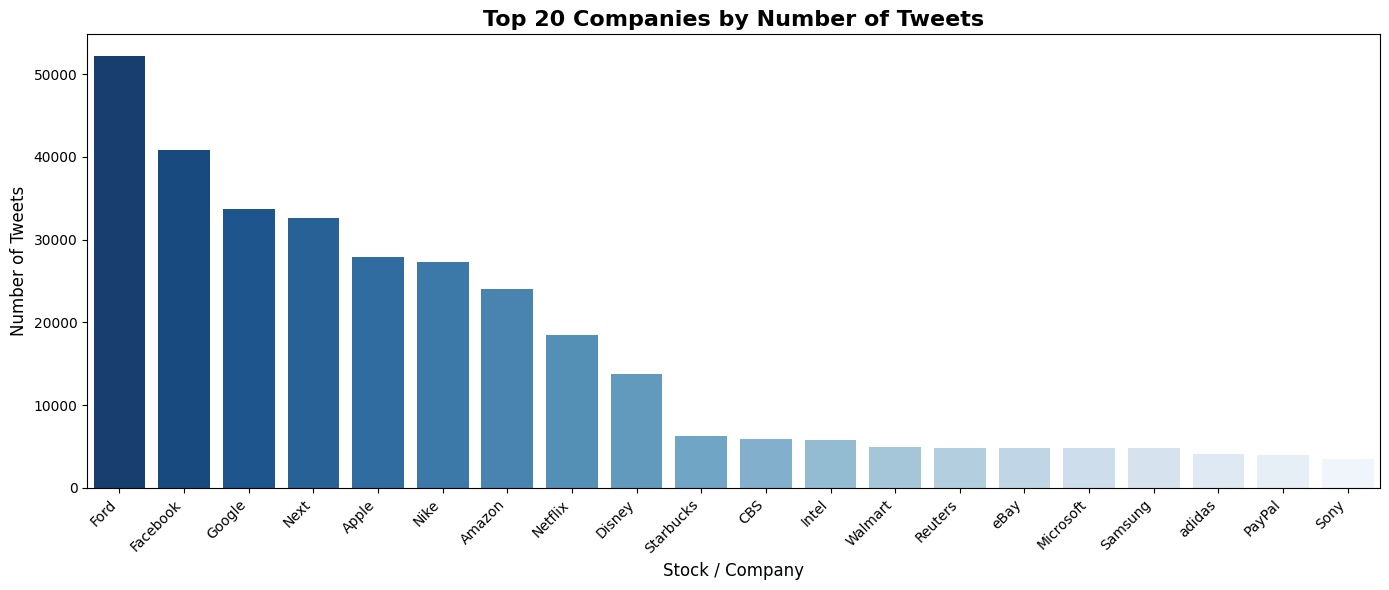

Most tweeted company: Ford with 52,198 tweets


In [8]:
# --- Bar chart: Tweets per stock ---
plt.figure(figsize=(14, 6))
stock_counts = df['STOCK'].value_counts().head(20)
sns.barplot(x=stock_counts.index, y=stock_counts.values, palette='Blues_r')
plt.title('Top 20 Companies by Number of Tweets', fontsize=16, fontweight='bold')
plt.xlabel('Stock / Company', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(f"Most tweeted company: {stock_counts.index[0]} with {stock_counts.values[0]:,} tweets")

In [9]:
# --- Date range analysis ---
date_column = None
for col in df.columns:
    if 'date' in col.lower() or 'time' in col.lower() or 'created' in col.lower():
        date_column = col
        break

if date_column:
    df[date_column] = pd.to_datetime(df[date_column], errors='coerce')
    
    # Drop NaT values before calculating range
    valid_dates = df[date_column].dropna()
    
    print("=" * 50)
    print(f"DATE RANGE ANALYSIS (column: '{date_column}')")
    print("=" * 50)
    
    if len(valid_dates) > 0:
        earliest = valid_dates.min()
        latest   = valid_dates.max()
        
        print(f"Earliest tweet : {earliest}")
        print(f"Latest tweet   : {latest}")
        
        # Fix: convert to Python native datetime before subtracting
        # This avoids the pandas OutOfBoundsDatetime overflow error
        try:
            delta = latest.to_pydatetime() - earliest.to_pydatetime()
            print(f"Date range     : {delta.days} days")
        except Exception:
            print(f"Date range     : Unable to calculate (dates may be out of bounds)")
        
        print(f"Valid date rows : {len(valid_dates):,} out of {len(df):,}")
    else:
        print("No valid dates found after parsing.")
else:
    print("No date column found in dataset.")

DATE RANGE ANALYSIS (column: 'DATE')
Earliest tweet : 1703-05-01 00:00:00
Latest tweet   : 2248-05-01 00:00:00
Date range     : 199058 days
Valid date rows : 369,458 out of 981,410


C:\Users\hafiz\AppData\Local\Temp\ipykernel_3340\2407055537.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_column] = pd.to_datetime(df[date_column], errors='coerce')


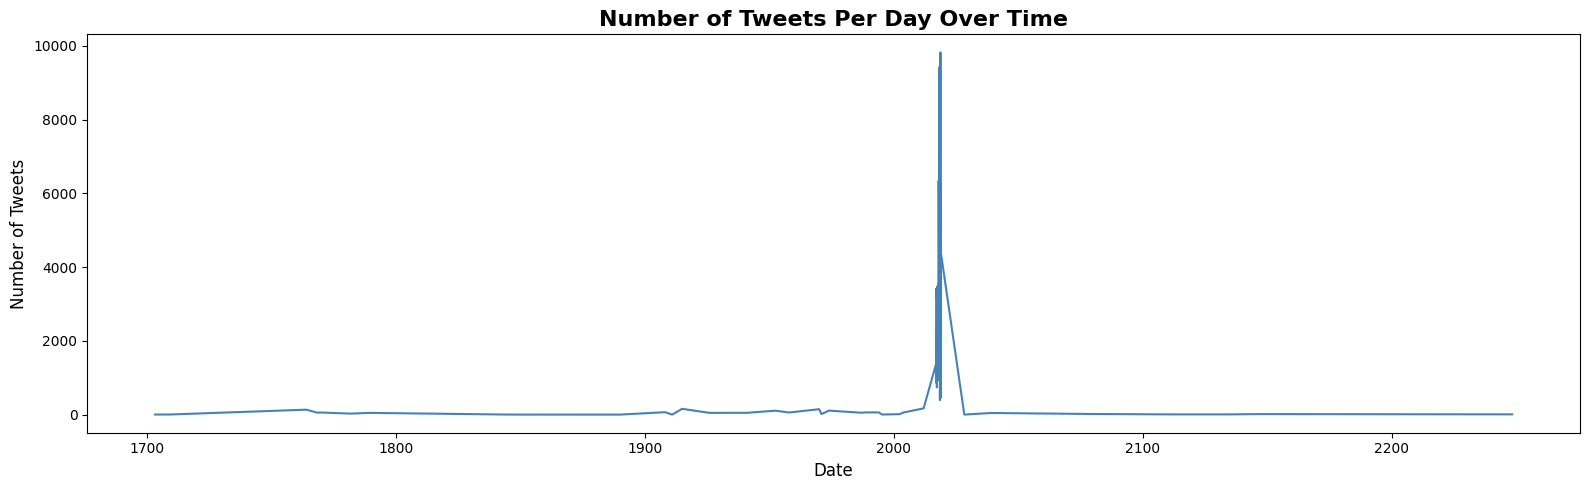

Average tweets per day: 2324
Peak tweets in a day  : 9,820 on 2018-09-27


In [10]:
# --- Number of tweets per date (if date column exists) ---
if date_column and df[date_column].notna().sum() > 0:
    df['date_only'] = df[date_column].dt.date
    tweets_per_date = df.groupby('date_only').size()

    plt.figure(figsize=(16, 5))
    tweets_per_date.plot(kind='line', color='steelblue', linewidth=1.5)
    plt.title('Number of Tweets Per Day Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Tweets', fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"Average tweets per day: {tweets_per_date.mean():.0f}")
    print(f"Peak tweets in a day  : {tweets_per_date.max():,} on {tweets_per_date.idxmax()}")
else:
    print("Skipping date trend chart — no valid date column found.")

## Text Exploratory Data Analysis

In [11]:
# --- Drop rows with missing tweet text ---
print(f"Rows before dropping missing tweets: {len(df):,}")
df = df.dropna(subset=['TWEET'])
print(f"Rows after dropping missing tweets : {len(df):,}")

Rows before dropping missing tweets: 981,410
Rows after dropping missing tweets : 981,363


In [12]:
# --- Tweet length distribution ---
df['tweet_length'] = df['TWEET'].astype(str).apply(len)
df['word_count']   = df['TWEET'].astype(str).apply(lambda x: len(x.split()))

print("=" * 50)
print("TWEET LENGTH STATISTICS")
print("=" * 50)
print(f"Average tweet length (chars) : {df['tweet_length'].mean():.1f}")
print(f"Average tweet word count     : {df['word_count'].mean():.1f}")
print(f"Shortest tweet               : {df['tweet_length'].min()} characters")
print(f"Longest tweet                : {df['tweet_length'].max()} characters")

TWEET LENGTH STATISTICS
Average tweet length (chars) : 105.3
Average tweet word count     : 15.1
Shortest tweet               : 2 characters
Longest tweet                : 352 characters


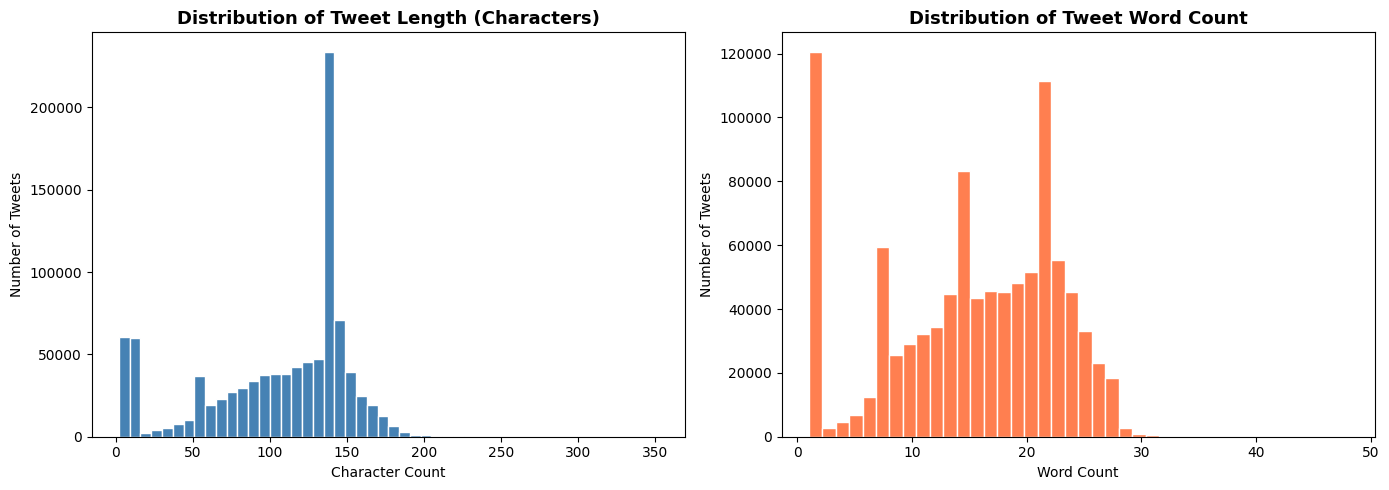

In [13]:
# --- Tweet length histogram ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['tweet_length'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Tweet Length (Characters)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Number of Tweets')

axes[1].hist(df['word_count'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Tweet Word Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Number of Tweets')

plt.tight_layout()
plt.show()

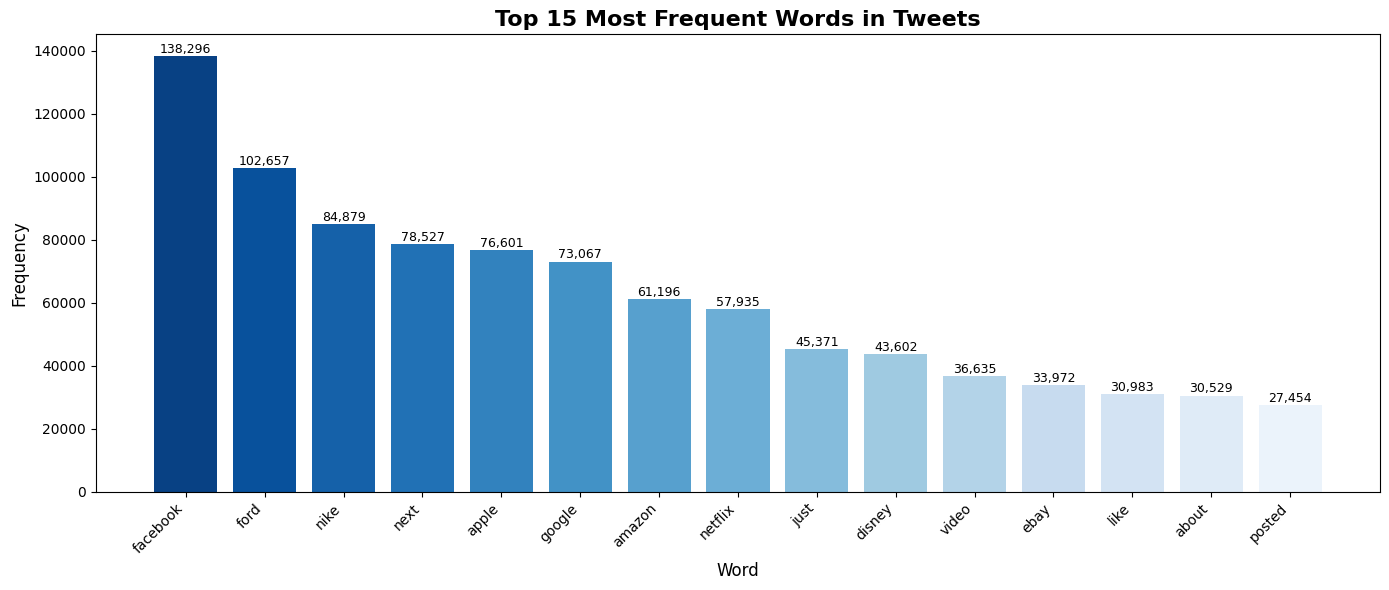

In [14]:
# --- Top 15 most frequent words (basic word frequency) ---
all_tweets_text = ' '.join(df['TWEET'].astype(str)).lower()
words = re.findall(r'\b[a-z]{4,}\b', all_tweets_text)

# Remove common noise words that are not meaningful
noise_words = ['http', 'https', 'that', 'this', 'with', 'from', 'have', 'will',
               'your', 'they', 'been', 'were', 'said', 'what', 'when', 'their']
meaningful_words = [w for w in words if w not in noise_words]

word_counts = Counter(meaningful_words)
top_15 = word_counts.most_common(15)
top_words = [w[0] for w in top_15]
top_counts = [w[1] for w in top_15]

plt.figure(figsize=(14, 6))
bars = plt.bar(top_words, top_counts, color=sns.color_palette('Blues_r', 15))
plt.title('Top 15 Most Frequent Words in Tweets', fontsize=16, fontweight='bold')
plt.xlabel('Word', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
for bar, count in zip(bars, top_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

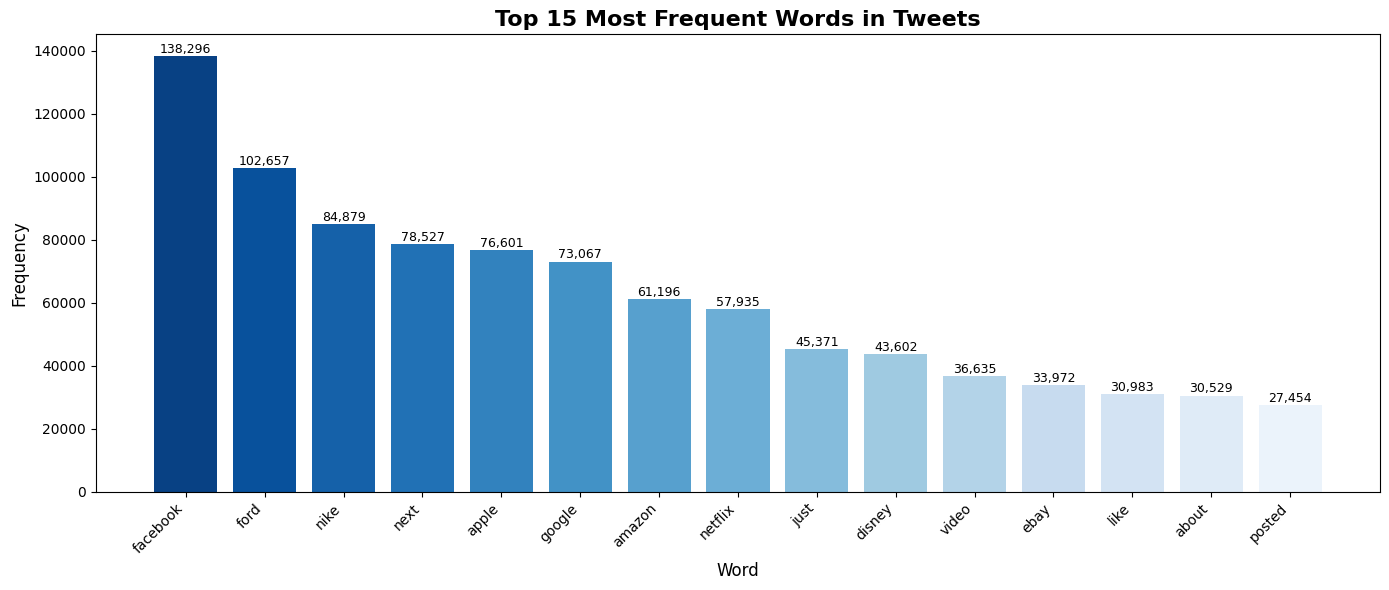

In [15]:
# --- Top 15 most frequent words (basic word frequency) ---
all_tweets_text = ' '.join(df['TWEET'].astype(str)).lower()
words = re.findall(r'\b[a-z]{4,}\b', all_tweets_text)

# Remove common noise words that are not meaningful
noise_words = ['http', 'https', 'that', 'this', 'with', 'from', 'have', 'will',
               'your', 'they', 'been', 'were', 'said', 'what', 'when', 'their']
meaningful_words = [w for w in words if w not in noise_words]

word_counts = Counter(meaningful_words)
top_15 = word_counts.most_common(15)
top_words = [w[0] for w in top_15]
top_counts = [w[1] for w in top_15]

plt.figure(figsize=(14, 6))
bars = plt.bar(top_words, top_counts, color=sns.color_palette('Blues_r', 15))
plt.title('Top 15 Most Frequent Words in Tweets', fontsize=16, fontweight='bold')
plt.xlabel('Word', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
for bar, count in zip(bars, top_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Preprocessing


### Intsall Libraries & Download NLTK Resources

In [16]:
# Install required libraries
!{sys.executable} -m pip install nltk wordcloud afinn scikit-learn seaborn textblob --quiet

import nltk

# Download all required NLTK resources
nltk.download('punkt')                      # Tokenization rules
nltk.download('punkt_tab')                  # Updated tokenization
nltk.download('stopwords')                  # Stopword list
nltk.download('wordnet')                    # Dictionary for lemmatization
nltk.download('omw-1.4')                    # Supporting data for wordnet
nltk.download('averaged_perceptron_tagger_eng')  # POS tagging
nltk.download('maxent_ne_chunker_tab')      # NER chunker
nltk.download('words')                      # Required for NER
nltk.download('vader_lexicon')              # VADER sentiment

print("\nAll resources downloaded successfully!")


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...



All resources downloaded successfully!


[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hafiz\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## Data Cleaning

In [17]:
import re

def clean_noise(text):
    """
    Removes URLs, @mentions, hashtags, special characters, and extra whitespace.
    Also applies case folding (lowercase).
    """
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)   # Remove URLs
    text = re.sub(r'@\w+', '', text)                         # Remove @mentions
    text = re.sub(r'#\w+', '', text)                         # Remove #hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)                  # Remove special chars & numbers
    text = text.lower()                                        # Case folding
    text = re.sub(r'\s+', ' ', text).strip()                 # Remove extra whitespace
    return text

# Apply to TWEET column and save in new column
df['clean_text'] = df['TWEET'].apply(clean_noise)

# Preview result
print("Before cleaning:")
print(df['TWEET'].iloc[0])
print("\nAfter cleaning:")
print(df['clean_text'].iloc[0])

Before cleaning:
RT @robertoglezcano: @amazon  #Patents Show Flying Warehouses That Send Delivery Drones To Your Door https://t.co/cZwL9QLhoC by… 

After cleaning:
rt show flying warehouses that send delivery drones to your door by


## Sentence Segmentation

In [18]:
from nltk.tokenize import sent_tokenize

# Apply sentence segmentation on the ORIGINAL tweet (before cleaning)
# We use raw text here because we want to preserve sentence boundaries
df['sentences'] = df['TWEET'].apply(sent_tokenize)

# Show example
print("Original tweet:")
print(df['TWEET'].iloc[0])
print("\nSentences:")
for i, s in enumerate(df['sentences'].iloc[0]):
    print(f"  Sentence {i+1}: {s}")

Original tweet:
RT @robertoglezcano: @amazon  #Patents Show Flying Warehouses That Send Delivery Drones To Your Door https://t.co/cZwL9QLhoC by… 

Sentences:
  Sentence 1: RT @robertoglezcano: @amazon  #Patents Show Flying Warehouses That Send Delivery Drones To Your Door https://t.co/cZwL9QLhoC by…


## Tokenization

In [19]:
from nltk.tokenize import word_tokenize

def tokenize_text(text):
    """
    Tokenizes text into words and removes punctuation.
    isalpha() keeps only words with letters (no numbers, no symbols).
    """
    tokens = word_tokenize(str(text))
    # Remove punctuation — keep only alphabetical tokens
    tokens = [word for word in tokens if word.isalpha()]
    return tokens

df['tokens'] = df['clean_text'].apply(tokenize_text)

# Preview
print("Cleaned text:")
print(df['clean_text'].iloc[0])
print("\nTokens:")
print(df['tokens'].iloc[0])

Cleaned text:
rt show flying warehouses that send delivery drones to your door by

Tokens:
['rt', 'show', 'flying', 'warehouses', 'that', 'send', 'delivery', 'drones', 'to', 'your', 'door', 'by']


## Handling Abbreviations

In [20]:
# Abbreviation dictionary — tailored for stock market / financial tweets
abbreviation_dict = {
    'rt'  : 'retweet',
    'roi' : 'return on investment',
    'ipo' : 'initial public offering',
    'etf' : 'exchange traded fund',
    'vix' : 'volatility index',
    'pe'  : 'price earnings',
    'eps' : 'earnings per share',
    'ytd' : 'year to date',
    'q'   : 'quarter',
    'u'   : 'you',
    'ur'  : 'your',
    'dm'  : 'direct message',
    'omg' : 'oh my god',
    'lol' : 'laugh out loud',
    'imo' : 'in my opinion',
    'ngl' : 'not going to lie',
    'tbh' : 'to be honest',
    'asap': 'as soon as possible',
    'fyi' : 'for your information',
}

def expand_abbreviations(token_list):
    """
    Replaces abbreviations in the token list with their full forms.
    Returns a flat list of tokens after expansion.
    """
    expanded = []
    for word in token_list:
        expanded_word = abbreviation_dict.get(word.lower(), word)
        expanded.extend(expanded_word.split())
    return expanded

df['expanded_tokens'] = df['tokens'].apply(expand_abbreviations)

# Preview
print("Tokens before abbreviation expansion:")
print(df['tokens'].iloc[0])
print("\nTokens after abbreviation expansion:")
print(df['expanded_tokens'].iloc[0])

Tokens before abbreviation expansion:
['rt', 'show', 'flying', 'warehouses', 'that', 'send', 'delivery', 'drones', 'to', 'your', 'door', 'by']

Tokens after abbreviation expansion:
['retweet', 'show', 'flying', 'warehouses', 'that', 'send', 'delivery', 'drones', 'to', 'your', 'door', 'by']


## Stopword Removal

In [21]:
from nltk.corpus import stopwords

# Load NLTK English stopwords
stop_words = set(stopwords.words('english'))

# Add custom stopwords relevant to the stock tweet dataset
custom_stopwords = [
    'next', 'via', 'amp', 'rt', 'co',
    'stock', 'market', 'share', 'price',   # too generic for this dataset
    'today', 'year', 'time', 'make', 'said'
]
stop_words.update(custom_stopwords)

def remove_stopwords(token_list):
    """
    Removes stopwords from the token list.
    Only keeps words that are NOT in the stopword set.
    """
    return [word for word in token_list if word not in stop_words]

df['filtered_tokens'] = df['expanded_tokens'].apply(remove_stopwords)

# Preview — compare before and after
print(f"Tokens before stopword removal ({len(df['expanded_tokens'].iloc[0])} words):")
print(df['expanded_tokens'].iloc[0])
print(f"\nTokens after stopword removal ({len(df['filtered_tokens'].iloc[0])} words):")
print(df['filtered_tokens'].iloc[0])

Tokens before stopword removal (12 words):
['retweet', 'show', 'flying', 'warehouses', 'that', 'send', 'delivery', 'drones', 'to', 'your', 'door', 'by']

Tokens after stopword removal (8 words):
['retweet', 'show', 'flying', 'warehouses', 'send', 'delivery', 'drones', 'door']


## Stemming & Lemmatization

In [22]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def apply_stemming(token_list):
    """Applies Porter Stemmer — chops word endings using rules."""
    return [stemmer.stem(word) for word in token_list]

def apply_lemmatization(token_list):
    """Applies WordNet Lemmatizer — looks up dictionary root form."""
    return [lemmatizer.lemmatize(word) for word in token_list]

df['stemmed_words']    = df['filtered_tokens'].apply(apply_stemming)
df['lemmatized_words'] = df['filtered_tokens'].apply(apply_lemmatization)

print("Stemming and Lemmatization complete!")
print("\nExample comparison:")
print(f"Filtered tokens  : {df['filtered_tokens'].iloc[0]}")
print(f"Stemmed          : {df['stemmed_words'].iloc[0]}")
print(f"Lemmatized       : {df['lemmatized_words'].iloc[0]}")

Stemming and Lemmatization complete!

Example comparison:
Filtered tokens  : ['retweet', 'show', 'flying', 'warehouses', 'send', 'delivery', 'drones', 'door']
Stemmed          : ['retweet', 'show', 'fli', 'warehous', 'send', 'deliveri', 'drone', 'door']
Lemmatized       : ['retweet', 'show', 'flying', 'warehouse', 'send', 'delivery', 'drone', 'door']


In [23]:
# --- Full pipeline comparison for one tweet ---
row = 5   # Change this to inspect different tweets

print("FULL PREPROCESSING PIPELINE COMPARISON")
print("=" * 60)
print(f"1. ORIGINAL TWEET:\n   {df['TWEET'].iloc[row]}")
print(f"\n2. CLEANED (noise removed, lowercased):\n   {df['clean_text'].iloc[row]}")
print(f"\n3. TOKENIZED (words split, punctuation removed):\n   {df['tokens'].iloc[row]}")
print(f"\n4. ABBREVIATIONS EXPANDED:\n   {df['expanded_tokens'].iloc[row]}")
print(f"\n5. STOPWORDS REMOVED:\n   {df['filtered_tokens'].iloc[row]}")
print(f"\n6a. STEMMED (chopped endings):\n   {df['stemmed_words'].iloc[row]}")
print(f"\n6b. LEMMATIZED (dictionary root — USE THIS):\n   {df['lemmatized_words'].iloc[row]}")

FULL PREPROCESSING PIPELINE COMPARISON
1. ORIGINAL TWEET:
   RT @loadsofvans: Retweet this post &amp; follow @loadsofvans for a chance to win a £100 @amazon voucher #win #giveaway #competition… 

2. CLEANED (noise removed, lowercased):
   rt retweet this post amp follow for a chance to win a voucher

3. TOKENIZED (words split, punctuation removed):
   ['rt', 'retweet', 'this', 'post', 'amp', 'follow', 'for', 'a', 'chance', 'to', 'win', 'a', 'voucher']

4. ABBREVIATIONS EXPANDED:
   ['retweet', 'retweet', 'this', 'post', 'amp', 'follow', 'for', 'a', 'chance', 'to', 'win', 'a', 'voucher']

5. STOPWORDS REMOVED:
   ['retweet', 'retweet', 'post', 'follow', 'chance', 'win', 'voucher']

6a. STEMMED (chopped endings):
   ['retweet', 'retweet', 'post', 'follow', 'chanc', 'win', 'voucher']

6b. LEMMATIZED (dictionary root — USE THIS):
   ['retweet', 'retweet', 'post', 'follow', 'chance', 'win', 'voucher']


## Pos Tagging

In [ ]:
import nltk

def apply_pos_tagging(token_list):
    """Applies POS tagging to a list of tokens."""
    return nltk.pos_tag(token_list)

# Apply POS tagging to lemmatized words
df['pos_tags'] = df['lemmatized_words'].apply(apply_pos_tagging)

# Preview
print("Lemmatized tokens:")
print(df['lemmatized_words'].iloc[0])
print("\nPOS Tags:")
print(df['pos_tags'].iloc[0])
print("\nPOS Tag reference: NN=Noun, VB=Verb, JJ=Adjective, RB=Adverb, NNP=Proper Noun")

In [ ]:
# --- Most common POS tags in the dataset ---
all_tags = []
for tag_list in df['pos_tags']:
    all_tags.extend([tag for _, tag in tag_list])

tag_counts = Counter(all_tags).most_common(10)
tag_labels = [t[0] for t in tag_counts]
tag_values = [t[1] for t in tag_counts]

plt.figure(figsize=(12, 5))
sns.barplot(x=tag_labels, y=tag_values, palette='coolwarm')
plt.title('Top 10 Most Common POS Tags in Tweets', fontsize=14, fontweight='bold')
plt.xlabel('POS Tag')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Chunking

In [ ]:
# Define a grammar rule to extract Noun Phrases (NP)
# Rule: optional determiner + any adjectives + a noun
grammar = "NP: {<DT>?<JJ>*<NN.*>+}"
chunk_parser = nltk.RegexpParser(grammar)

def extract_noun_phrases(pos_tagged_tokens):
    """Extracts noun phrases from POS-tagged tokens using chunking."""
    tree = chunk_parser.parse(pos_tagged_tokens)
    noun_phrases = []
    for subtree in tree.subtrees():
        if subtree.label() == 'NP':
            phrase = ' '.join(word for word, tag in subtree.leaves())
            noun_phrases.append(phrase)
    return noun_phrases

df['noun_phrases'] = df['pos_tags'].apply(extract_noun_phrases)

# Preview
print("POS Tags:")
print(df['pos_tags'].iloc[0])
print("\nExtracted Noun Phrases:")
print(df['noun_phrases'].iloc[0])

In [ ]:
# --- Top 15 most common noun phrases across all tweets ---
all_noun_phrases = []
for phrase_list in df['noun_phrases']:
    all_noun_phrases.extend(phrase_list)

np_counts = Counter(all_noun_phrases).most_common(15)
np_words  = [n[0] for n in np_counts]
np_values = [n[1] for n in np_counts]

plt.figure(figsize=(14, 6))
sns.barplot(x=np_values, y=np_words, palette='viridis')
plt.title('Top 15 Most Common Noun Phrases in Stock Tweets', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Noun Phrase')
plt.tight_layout()
plt.show()

## Named Entity Recognition

In [ ]:
def apply_ner(raw_text):
    """
    Applies Named Entity Recognition to RAW text (not cleaned).
    NER needs original capitalisation to identify proper nouns.
    Returns a list of (entity_text, entity_type) tuples.
    """
    tokens  = nltk.word_tokenize(str(raw_text))
    pos_tag = nltk.pos_tag(tokens)
    tree    = nltk.ne_chunk(pos_tag)
    
    entities = []
    for chunk in tree:
        if hasattr(chunk, 'label'):
            entity_text = ' '.join(c[0] for c in chunk)
            entity_type = chunk.label()
            entities.append((entity_text, entity_type))
    return entities

# Apply to a sample (NER is slow — run on first 500 rows for demonstration)
print("Applying NER to sample of 500 tweets (this may take a moment)...")
df_sample_ner = df.head(500).copy()
df_sample_ner['ner_entities'] = df_sample_ner['TWEET'].apply(apply_ner)

# Store back into main df for the sample rows
df.loc[df_sample_ner.index, 'ner_entities'] = df_sample_ner['ner_entities']

print("NER complete!")
print("\nExample:")
print(f"Tweet   : {df['TWEET'].iloc[0]}")
print(f"Entities: {df_sample_ner['ner_entities'].iloc[0]}")

In [ ]:
# --- Most frequently identified entities and their types ---
all_entities = []
for ent_list in df_sample_ner['ner_entities']:
    all_entities.extend(ent_list)

if all_entities:
    entity_df = pd.DataFrame(all_entities, columns=['Entity', 'Type'])
    
    print("=" * 50)
    print("TOP 15 MOST FREQUENT ENTITIES")
    print("=" * 50)
    print(entity_df['Entity'].value_counts().head(15))
    
    print("\n" + "=" * 50)
    print("ENTITY TYPE DISTRIBUTION")
    print("=" * 50)
    print(entity_df['Type'].value_counts())
    
    # Plot entity type distribution
    plt.figure(figsize=(8, 5))
    entity_df['Type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title('Named Entity Types Found in Stock Tweets', fontsize=14, fontweight='bold')
    plt.xlabel('Entity Type')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No entities found in the sample.")

## Word Cloud Visualisation

In [ ]:
from wordcloud import WordCloud

# Join all lemmatized words into one big string
all_clean_words = []
for word_list in df['lemmatized_words']:
    all_clean_words.extend(word_list)

text_for_cloud = ' '.join(all_clean_words)

# Generate the word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='Blues',
    max_words=150,
    collocations=False   # Avoid repeating word pairs
).generate(text_for_cloud)

# Plot
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Most Frequent Words in Stock Market Tweets',
          fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
print(f"Word cloud generated from {len(all_clean_words):,} cleaned tokens.")

In [ ]:
# --- Word cloud per company (top 3 stocks) ---
top_3_stocks = df['STOCK'].value_counts().head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, stock in zip(axes, top_3_stocks):
    stock_words = []
    for word_list in df[df['STOCK'] == stock]['lemmatized_words']:
        stock_words.extend(word_list)
    
    if stock_words:
        wc = WordCloud(width=600, height=400, background_color='white',
                       colormap='viridis', max_words=80).generate(' '.join(stock_words))
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'Word Cloud — {stock}', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Clouds by Top 3 Companies', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature Engineering

- TF-IDF Features
- Word Embedding Features
- BERT Embeddings

### TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Join lemmatized tokens back into a string for TF-IDF
# TF-IDF requires a string input, not a list
df['joined_tokens'] = df['lemmatized_words'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else ''
)

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,        # Keep top 1000 words only
    stop_words='english',     # Additional stopword removal
    ngram_range=(1, 2),       # Include single words AND 2-word phrases
)

# Fit and transform — learns vocabulary AND converts to numbers
tfidf_matrix = tfidf_vectorizer.fit_transform(df['joined_tokens'])

# Convert to readable DataFrame
feature_names = tfidf_vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=df.index
)

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"(Rows = tweets, Columns = unique words/phrases)")
print(f"\nThis is called a SPARSE MATRIX because most values are 0.0")
print(f"Non-zero values: {tfidf_matrix.nnz:,} out of {tfidf_matrix.shape[0] * tfidf_matrix.shape[1]:,} total")
print(f"Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.1f}% zeros")
df_tfidf.head()

In [ ]:
# --- Top TF-IDF terms overall ---
mean_tfidf = df_tfidf.mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 6))
sns.barplot(x=mean_tfidf.values, y=mean_tfidf.index, palette='Blues_r')
plt.title('Top 20 Words by Average TF-IDF Score', fontsize=14, fontweight='bold')
plt.xlabel('Mean TF-IDF Score')
plt.ylabel('Word / Phrase')
plt.tight_layout()
plt.show()
print("Higher score = more unique and important to specific tweets")

In [ ]:
# --- TF-IDF top terms per stock company ---
top_stocks_tfidf = df['STOCK'].value_counts().head(3).index.tolist()

print("=" * 60)
print("TOP 10 TF-IDF TERMS PER COMPANY")
print("=" * 60)

for stock in top_stocks_tfidf:
    stock_indices = df.index[df['STOCK'] == stock]
    if len(stock_indices) > 0:
        stock_tfidf_mean = df_tfidf.loc[stock_indices].mean().sort_values(ascending=False).head(10)
        print(f"\n{stock}:")
        for term, score in stock_tfidf_mean.items():
            print(f"  {term:<25} {score:.4f}")

### Word Embeddeding Features

In [ ]:
try:
    from gensim.models import Word2Vec
    GENSIM_AVAILABLE = True
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'gensim', '--quiet'])
    from gensim.models import Word2Vec
    GENSIM_AVAILABLE = True

import numpy as np

# Prepare sentences — list of token lists
sentences = df['lemmatized_words'].tolist()
sentences = [s for s in sentences if isinstance(s, list) and len(s) > 0]

# Train Word2Vec model on our tweet corpus
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,    # 100-dimensional word vectors
    window=5,           # Context window size
    min_count=2,        # Ignore words appearing less than 2 times
    workers=4,          # Parallel threads
    epochs=10
)

print(f"Word2Vec model trained!")
print(f"Vocabulary size: {len(w2v_model.wv):,} words")
print(f"Vector dimensions: {w2v_model.vector_size}")

# Example: most similar words
try:
    print(f"\nWords most similar to 'stock':")
    for word, score in w2v_model.wv.most_similar('stock', topn=5):
        print(f"  {word:<20} similarity: {score:.3f}")
except KeyError:
    print("\n'stock' not in vocabulary — try another word")

In [ ]:
import numpy as np

def get_tweet_embedding(token_list, model, vector_size=100):
    """
    Converts a list of tokens into a single vector by averaging
    the word vectors of all known words in the tweet.
    """
    vectors = []
    for word in token_list:
        if word in model.wv:
            vectors.append(model.wv[word])
    
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)  # Return zero vector if no known words

# Generate embeddings for all tweets
embeddings = df['lemmatized_words'].apply(
    lambda x: get_tweet_embedding(x if isinstance(x, list) else [], w2v_model)
)

# Convert to DataFrame
embedding_cols = [f'w2v_{i}' for i in range(w2v_model.vector_size)]
df_embeddings = pd.DataFrame(embeddings.tolist(), columns=embedding_cols, index=df.index)

print(f"Word2Vec embeddings shape: {df_embeddings.shape}")
print(f"Each tweet is now represented as a {w2v_model.vector_size}-dimensional vector")
df_embeddings.head(3)

### BERT Embeddings

In [ ]:
try:
    from sentence_transformers import SentenceTransformer
    SBERT_AVAILABLE = True
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'sentence-transformers', '--quiet'])
    from sentence_transformers import SentenceTransformer
    SBERT_AVAILABLE = True

# Load a lightweight pre-trained BERT model
print("Loading BERT model (this may take a moment on first run)...")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')  # Small but effective model
print("BERT model loaded!")

# Apply to a sample of tweets (BERT is slow on large datasets)
sample_size = min(500, len(df))
df_bert_sample = df.head(sample_size).copy()

print(f"\nGenerating BERT embeddings for {sample_size} tweets...")
bert_embeddings = bert_model.encode(
    df_bert_sample['TWEET'].astype(str).tolist(),
    show_progress_bar=True,
    batch_size=32
)

print(f"\nBERT Embeddings shape: {bert_embeddings.shape}")
print(f"Each tweet is represented as a {bert_embeddings.shape[1]}-dimensional BERT vector")

In [ ]:
# --- Compare TF-IDF vs Word2Vec vs BERT ---
print("=" * 60)
print("FEATURE COMPARISON SUMMARY")
print("=" * 60)

comparison_data = {
    'Feature Type'   : ['TF-IDF', 'Word2Vec', 'BERT'],
    'Dimensions'     : [1000, 100, 384],
    'Type'           : ['Sparse (mostly zeros)', 'Dense (all values)', 'Dense (contextual)'],
    'Context Aware'  : ['No', 'Partial', 'Yes — fully contextual'],
    'Training'       : ['No training needed', 'Trained on our data', 'Pre-trained on massive corpus'],
    'Best For'       : ['Traditional ML models', 'Custom embeddings', 'Deep learning / transformers'],
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

### Preprocessing Summary

In [ ]:
print("=" * 60)
print("PREPROCESSING PIPELINE — COLUMNS CREATED")
print("=" * 60)
pipeline_columns = {
    'TWEET'             : 'Original raw tweet text',
    'clean_text'        : 'Noise removed + lowercased',
    'sentences'         : 'Split into individual sentences',
    'tokens'            : 'Tokenized + punctuation removed',
    'expanded_tokens'   : 'Abbreviations expanded',
    'filtered_tokens'   : 'Stopwords removed',
    'stemmed_words'     : 'Stemmed (Porter Stemmer)',
    'lemmatized_words'  : 'Lemmatized (WordNet) ← USE THIS',
    'pos_tags'          : 'Part-of-Speech tags assigned',
    'noun_phrases'      : 'Noun phrases extracted (chunking)',
    'ner_entities'      : 'Named entities identified',
    'joined_tokens'     : 'Lemmatized tokens joined as string',
}

for col, desc in pipeline_columns.items():
    status = '✓' if col in df.columns else '—'
    print(f"  {status}  {col:<22}  {desc}")

print(f"\nDataset ready for Sentiment Analysis!")
print(f"Total tweets: {len(df):,}")

# Sentiment Analysis

- TextBlob polarity
- VADER polarity
- Positive/Negative/Neutral labels

## Sentiment EDA 
   - Sentiment distribution
   - Sentiment by company
   - Sentiment over time
   - Sentiment vs stock return

# Opinion Mining

## Opinion Word Extraction

## Opinion Target Extraction

## Dependancy Parsing

# Aspect-Based Sentiment Analysis

## Aspect Extraction Using spaCy

## Aspect Categorization

## Aspect Sentiment Classification

## Aspect-Wise Sentiment Visualisation

# Modelling

- Feature selection
- Train-test split
- Model training
- Model evaluation

## Traditional ML Model - [letak nama model]

## Deep Learning Model - [letak nama model]

## Transformer Model - [letak nama model]

# Model Evaluation

## Accuracy

## Precision

## Recall

## F1-Score

## Confusion Matrix

## Model Comparison

# Stock Price Impact Analysis

# Conclusion